Executando 30 rodadas...

--- Relatório Final (30 rodadas) ---
Métrica              | Simulated Annealing  | Hill Climbing       
-----------------------------------------------------------------
Média Custo          | 457.45               | 458.41              
Desvio Padrão        | 1.60                 | 1.92                
Melhor Custo         | 456.49               | 456.49              
Média Avaliações     | 52662                | 52662               

Teste de Wilcoxon (P-Value): 4.1840e-04
Conclusão: Existe diferença estatisticamente significativa entre os algoritmos.


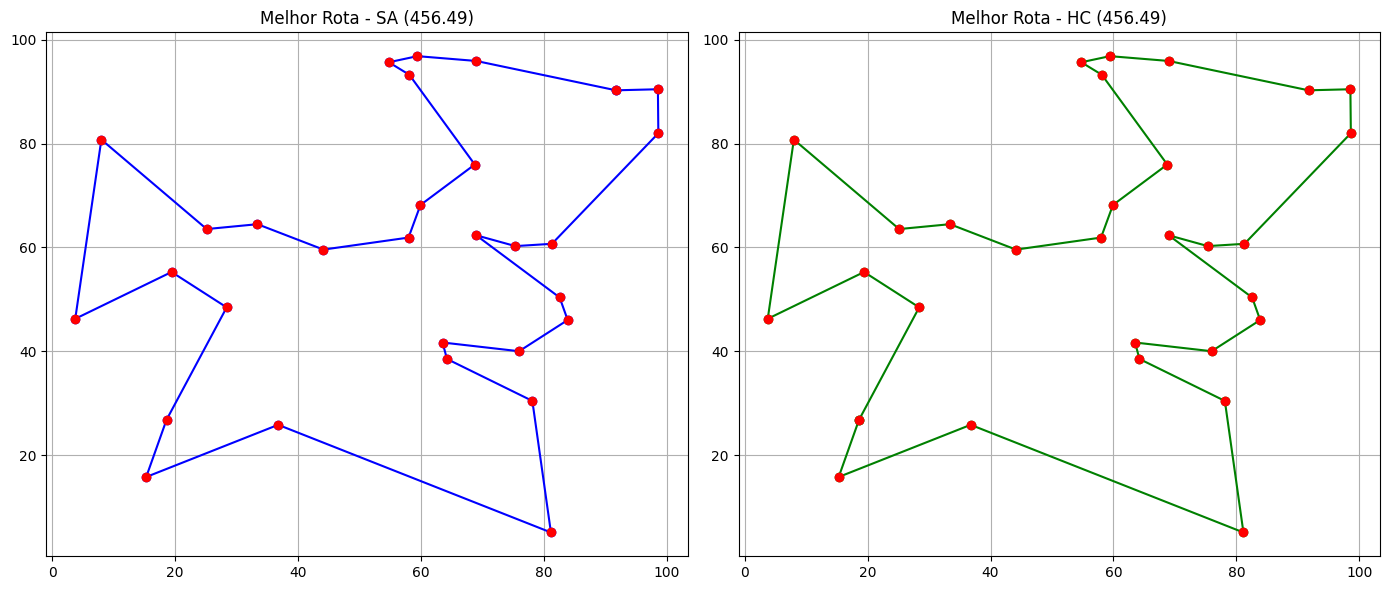

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

# ==========================================
# 1. Funções Base
# ==========================================

def gerar_instancia(n, seed=90):
    np.random.seed(seed)
    return np.random.uniform(0, 100, size=(n, 2))

def matriz_dist(coordenada, n):
    dist_mat = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            dist_mat[i, j] = np.sqrt(np.sum((coordenada[i] - coordenada[j])**2))
    return dist_mat

def custo_total(tour, dist_matrix):
    custo = 0
    n = len(tour)
    for i in range(n):
        custo += dist_matrix[tour[i], tour[(i + 1) % n]]
    return custo

# ==========================================
# 2. Calibração do SA
# ==========================================

def calibracao(n, dist_mat, tentativas=1000):
    pioras = []
    tour = np.random.permutation(n)
    for _ in range(tentativas):
        i, j = sorted(np.random.choice(n, size=2, replace=False))
        if j == i + 1 or (i == 0 and j == n - 1):
            continue

        a, b = tour[i], tour[(i + 1) % n]
        c, d = tour[j], tour[(j + 1) % n]
        delta_f = (dist_mat[a, c] + dist_mat[b, d]) - (dist_mat[a, b] + dist_mat[c, d])

        if delta_f > 0:
            pioras.append(delta_f)
        tour[i+1 : j+1] = tour[i+1 : j+1][::-1]
    return pioras

def calcular_temperatura_inicial(pioras, x0=0.8):
    delta_f_medio = np.mean(pioras)
    return -delta_f_medio / np.log(x0)

# ==========================================
# 3. Metaheurísticas
# ==========================================

def simulated_annealing(n_cidades, dist_mat, T0, alpha=0.95, T_min=0.1, max_iter=405):
    tour = np.random.permutation(n_cidades)
    melhor_tour = tour.copy()
    custo_atual = custo_total(tour, dist_mat)
    melhor_custo = custo_atual

    T = T0
    evals = 0

    while T > T_min:
        for it in range(1, max_iter):
            i, j = sorted(np.random.choice(n_cidades, size=2, replace=False))
            if j == i + 1 or (i == 0 and j == n_cidades - 1):
                continue

            a, b = tour[i], tour[(i + 1) % n_cidades]
            c, d = tour[j], tour[(j + 1) % n_cidades]
            delta_f = (dist_mat[a, c] + dist_mat[b, d]) - (dist_mat[a, b] + dist_mat[c, d])
            evals += 1

            if ((delta_f < 0) or (np.random.uniform(0, 1) < np.exp(-delta_f/T))):
                tour[i+1 : j+1] = tour[i+1 : j+1][::-1]
                custo_atual += delta_f

                if custo_atual < melhor_custo:
                    melhor_custo = custo_atual
                    melhor_tour = tour.copy()
        T *= alpha

    return melhor_custo, melhor_tour, evals

def hill_climbing_reinicios(n_cidades, dist_mat, max_restarts, orcamento_max):
    melhor_custo_global = float('inf')
    melhor_tour_global = None
    evals_totais = 0
    reinicios_realizados = 0

    for _ in range(max_restarts):
        if evals_totais >= orcamento_max:
            break

        tour = np.random.permutation(n_cidades)
        custo_atual = custo_total(tour, dist_mat)
        reinicios_realizados += 1

        while evals_totais < orcamento_max:
            melhor_vizinho = None
            melhor_delta = 0

            # Busca Completa da Vizinhança
            for i in range(n_cidades):
                for j in range(i + 2, n_cidades):
                    if i == 0 and j == n_cidades - 1:
                        continue

                    if evals_totais >= orcamento_max:
                        break

                    a, b = tour[i], tour[(i + 1) % n_cidades]
                    c, d = tour[j], tour[(j + 1) % n_cidades]
                    delta_f = (dist_mat[a, c] + dist_mat[b, d]) - (dist_mat[a, b] + dist_mat[c, d])
                    evals_totais += 1

                    if delta_f < melhor_delta:
                        melhor_delta = delta_f
                        melhor_vizinho = (i, j)

                if evals_totais >= orcamento_max:
                    break

            if melhor_delta < 0:
                i, j = melhor_vizinho
                tour[i+1 : j+1] = tour[i+1 : j+1][::-1]
                custo_atual += melhor_delta
            else:
                break # Ótimo local alcançado

        if custo_atual < melhor_custo_global:
            melhor_custo_global = custo_atual
            melhor_tour_global = tour.copy()

    return melhor_custo_global, melhor_tour_global, evals_totais

# ==========================================
# 4. Execução do Experimento
# ==========================================

n = 30
num_execucoes = 30
max_reinicios_hc = 100

coords = gerar_instancia(n)
distancias = matriz_dist(coords, n)

# Calibração do SA
pioras = calibracao(n, distancias)
T0 = calcular_temperatura_inicial(pioras, x0=0.80)

resultados_sa = []
resultados_hc = []
tours_sa = []
tours_hc = []
evals_sa_list = []
evals_hc_list = []

print("Executando 30 rodadas...")
for i in range(num_execucoes):
    #SA
    np.random.seed(i)
    custo_sa, tour_sa, evals_sa = simulated_annealing(n, distancias, T0)
    resultados_sa.append(custo_sa)
    tours_sa.append(tour_sa)
    evals_sa_list.append(evals_sa)

    #HC
    np.random.seed(i)
    custo_hc, tour_hc, evals_hc = hill_climbing_reinicios(n, distancias, max_reinicios_hc, orcamento_max=evals_sa)
    resultados_hc.append(custo_hc)
    tours_hc.append(tour_hc)
    evals_hc_list.append(evals_hc)

# ==========================================
# 5. Relatórios e Estatísticas
# ==========================================

print(f"\n--- Relatório Final ({num_execucoes} rodadas) ---")
print(f"{'Métrica':<20} | {'Simulated Annealing':<20} | {'Hill Climbing':<20}")
print("-" * 65)
print(f"{'Média Custo':<20} | {np.mean(resultados_sa):<20.2f} | {np.mean(resultados_hc):<20.2f}")
print(f"{'Desvio Padrão':<20} | {np.std(resultados_sa, ddof=1):<20.2f} | {np.std(resultados_hc, ddof=1):<20.2f}")
print(f"{'Melhor Custo':<20} | {np.min(resultados_sa):<20.2f} | {np.min(resultados_hc):<20.2f}")
print(f"{'Média Avaliações':<20} | {np.mean(evals_sa_list):<20.0f} | {np.mean(evals_hc_list):<20.0f}")

# Teste de Wilcoxon
stat, p_value = wilcoxon(resultados_sa, resultados_hc)
print(f"\nTeste de Wilcoxon (P-Value): {p_value:.4e}")
if p_value < 0.05:
    print("Conclusão: Existe diferença estatisticamente significativa entre os algoritmos.")
else:
    print("Conclusão: Não existe diferença estatisticamente significativa.")

# ==========================================
# 6. Plotagem da Melhor Rota
# ==========================================

melhor_idx_sa = np.argmin(resultados_sa)
melhor_idx_hc = np.argmin(resultados_hc)

melhor_rota_sa = tours_sa[melhor_idx_sa]
melhor_rota_hc = tours_hc[melhor_idx_hc]

def plot_tour(ax, tour, coords, title, color):
    tour_coords = np.vstack((coords[tour], coords[tour[0]]))
    ax.plot(tour_coords[:, 0], tour_coords[:, 1], marker='o', linestyle='-', color=color)
    ax.scatter(coords[:, 0], coords[:, 1], color='red', zorder=5) # Cidades
    ax.set_title(title)
    ax.grid(True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
plot_tour(ax1, melhor_rota_sa, coords, f'Melhor Rota - SA ({np.min(resultados_sa):.2f})', 'blue')
plot_tour(ax2, melhor_rota_hc, coords, f'Melhor Rota - HC ({np.min(resultados_hc):.2f})', 'green')
plt.tight_layout()
plt.show()